# Structure optimization: water and ethanol

This notebook follows the [ASE H₂O structure-optimization tutorial](https://docs.ase-lib.org/examples_generated/01-gettingstarted/02-h2o-structure.html). It builds a water molecule, evaluates forces with GPAW, relaxes the atomic positions with BFGS, and then repeats the workflow for ethanol from ASE's G2 collection.

Unless stated otherwise, distances are in ångström (Å), energies are in electronvolts (eV), and forces are in eV/Å.

## Building and boxing a water molecule

The symbol string `HOH` and the three position rows define H(0), O(1), and H(2). These coordinates are only an initial guess; the optimizer will move the atoms according to the calculated forces.

`atoms.center(vacuum=3.0)` creates a finite three-dimensional cell and leaves at least 3 Å of empty space between the molecule and each cell face. The molecule remains non-periodic because its periodic-boundary flags are still false. The rotation passed to `plot_atoms` changes only the plotted viewpoint, not the atomic coordinates.

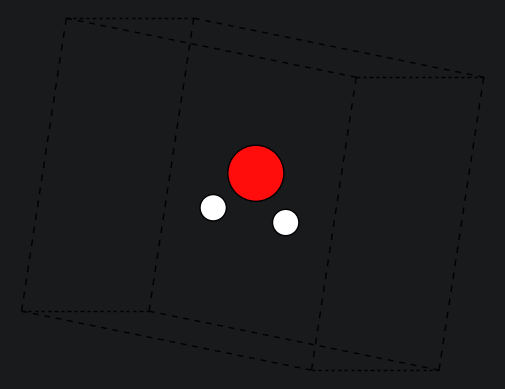

In [1]:
import matplotlib.pyplot as plt

from ase import Atoms
from ase.visualize.plot import plot_atoms

atoms = Atoms('HOH', positions=[[0, 0, -1], [0, 1, 0], [0, 0, 1]])
atoms.center(vacuum=3.0)

fig, ax = plt.subplots()
plot_atoms(atoms, ax, rotation='10x,60y,0z')
ax.set_axis_off()

## Attaching a GPAW calculator

GPAW supplies the potential energy and forces needed by the optimizer. In `lcao` mode, the electronic wave functions are expanded in localized atomic-orbital-like basis functions. The `dzp` basis is double-zeta polarized: it gives each valence state two radial functions and adds polarization functions, offering a relatively inexpensive starting point whose accuracy is still limited by the chosen basis.

Assigning the calculator does not yet run a calculation. GPAW starts when ASE first requests an energy or force. Its electronic-structure and self-consistent-field details are written to `gpaw_h2o.txt`; the optimizer uses separate trajectory and log files.

In [2]:
from gpaw import GPAW

calc = GPAW(mode='lcao', basis='dzp', txt='../files/tutorial_03/gpaw_h2o.txt')
atoms.calc = calc

## Geometry optimization with BFGS

BFGS updates the atomic positions using the force history to approach a local minimum of the potential-energy surface. No cell filter is supplied, so the simulation cell stays fixed while the nuclei move.

The run stops when the largest atomic force satisfies

$$
F_{max} = max_i |F_i| < 0.05 eV/Å.
$$

The trajectory stores the sequence of geometries, while the optimizer log records the step number, energy, and maximum force. A returned value of `np.True_` means that this convergence condition was met.

In [3]:
from ase.optimize import BFGS

opt = BFGS(atoms, trajectory='../files/tutorial_03/opt_h2o.traj', logfile='../files/tutorial_03/opt_h2o.log')
opt.run(fmax=0.05)

np.True_

### Inspecting the water relaxation

The slice `':'` tells `read` to load every saved image rather than only the final one. Passing that sequence to `view` opens it as a trajectory, making it possible to inspect how the starting geometry evolves toward the optimized structure.

In [4]:
from ase.io import read
from ase.visualize import view

atoms = read('../files/tutorial_03/opt_h2o.traj', ':')
view(atoms)

<Popen: returncode: None args: ['/Users/liangze/Desktop/Experiences/ase_lear...>

### Measuring the optimized geometry

`get_angle(a, b, c)` measures the angle with atom `b` at the vertex. Because the atom order is H(0)–O(1)–H(2), `get_angle(0, 1, 2)` is the H–O–H bond angle. The stored result is about 103.45°. The other two values, about 38.27° each, are the remaining internal angles of the H–O–H triangle and are useful indexing checks rather than additional bond angles at oxygen.

This value belongs to the selected LCAO/DZP setup and force threshold; it should not be treated as a converged experimental benchmark.

In [5]:
from ase.io import read

atoms = read('../files/tutorial_03/opt_h2o.traj', ':')
print(atoms[-1].get_angle(0, 1, 2))
print(atoms[-1].get_angle(2, 0, 1))
print(atoms[-1].get_angle(1, 2, 0))

103.4548864563072
38.27255677184642
38.27255677184639


## Reusing structures from ASE collections

`molecule('H2O')` provides ASE's built-in water geometry, and its `vacuum=3.0` argument places that molecule in a finite non-periodic box just as above. ASE's G2 collection similarly provides named molecular starting structures; `g2.names` lists the available entries and `g2['CH3CH2OH']` selects ethanol.

A structure taken directly from G2 has atomic coordinates but no finite simulation cell. That is sufficient for viewing, but GPAW requires three non-zero cell vectors even for an isolated molecule, so the ethanol structure must be centered with vacuum before the calculator is used.

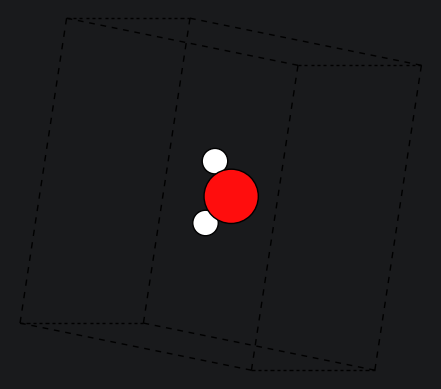

In [6]:
from ase.build import molecule

atoms = molecule('H2O', vacuum=3.0)
fig, ax = plt.subplots()
plot_atoms(atoms, ax, rotation='10x,60y,0z')
ax.set_axis_off()

In [7]:
from ase.collections import g2

print(g2.names)  # These are the molecule names
atoms = g2['CH3CH2OH']

['PH3', 'P2', 'CH3CHO', 'H2COH', 'CS', 'OCHCHO', 'C3H9C', 'CH3COF', 'CH3CH2OCH3', 'HCOOH', 'HCCl3', 'HOCl', 'H2', 'SH2', 'C2H2', 'C4H4NH', 'CH3SCH3', 'SiH2_s3B1d', 'CH3SH', 'CH3CO', 'CO', 'ClF3', 'SiH4', 'C2H6CHOH', 'CH2NHCH2', 'isobutene', 'HCO', 'bicyclobutane', 'LiF', 'Si', 'C2H6', 'CN', 'ClNO', 'S', 'SiF4', 'H3CNH2', 'methylenecyclopropane', 'CH3CH2OH', 'F', 'NaCl', 'CH3Cl', 'CH3SiH3', 'AlF3', 'C2H3', 'ClF', 'PF3', 'PH2', 'CH3CN', 'cyclobutene', 'CH3ONO', 'SiH3', 'C3H6_D3h', 'CO2', 'NO', 'trans-butane', 'H2CCHCl', 'LiH', 'NH2', 'CH', 'CH2OCH2', 'C6H6', 'CH3CONH2', 'cyclobutane', 'H2CCHCN', 'butadiene', 'C', 'H2CO', 'CH3COOH', 'HCF3', 'CH3S', 'CS2', 'SiH2_s1A1d', 'C4H4S', 'N2H4', 'OH', 'CH3OCH3', 'C5H5N', 'H2O', 'HCl', 'CH2_s1A1d', 'CH3CH2SH', 'CH3NO2', 'Cl', 'Be', 'BCl3', 'C4H4O', 'Al', 'CH3O', 'CH3OH', 'C3H7Cl', 'isobutane', 'Na', 'CCl4', 'CH3CH2O', 'H2CCHF', 'C3H7', 'CH3', 'O3', 'P', 'C2H4', 'NCCN', 'S2', 'AlCl3', 'SiCl4', 'SiO', 'C3H4_D2d', 'H', 'COF2', '2-butyne', 'C2H5', 'BF3'

### Visualizing one molecule or the collection

`view(atoms)` opens the selected ethanol structure, whereas `view(g2)` opens the full collection for browsing. In a notebook, the displayed `Popen` object is the handle for the separately launched ASE GUI process; it is not a molecular result.

In [8]:
view(atoms)
view(g2)

<Popen: returncode: None args: ['/Users/liangze/Desktop/Experiences/ase_lear...>

## Extending the workflow to ethanol

Before GPAW is attached, `atoms.center(vacuum=3.0)` gives ethanol a rank-three cell while leaving it non-periodic. This avoids the zero-cell error produced when GPAW receives the unboxed G2 structure.

A fresh GPAW calculator and separate output filenames keep the ethanol run independent of the water calculation. The same 0.05 eV/Å force threshold is used, but the larger molecule has more electronic and nuclear degrees of freedom and is therefore more expensive to relax.

In [9]:
atoms.center(vacuum=3.0)

calc = GPAW(mode='lcao', basis='dzp', txt='../files/tutorial_03/gpaw_ethanol.txt')
atoms.calc = calc

opt = BFGS(atoms, trajectory='../files/tutorial_03/opt_ethanol.traj', logfile='../files/tutorial_03/opt_ethanol.log')
opt.run(fmax=0.05)

np.True_

### Inspecting the ethanol trajectory

As for water, reading with `':'` loads all saved optimization frames. The final frame should be checked for a chemically sensible structure; optimizer convergence means the requested force threshold was reached, not that every numerical setting or possible molecular conformation has been explored.

In [10]:
atoms = read('../files/tutorial_03/opt_ethanol.traj', ':')
view(atoms)

<Popen: returncode: None args: ['/Users/liangze/Desktop/Experiences/ase_lear...>

## Takeaways and possible extensions

The reusable workflow is: construct a reasonable starting geometry, provide the finite cell required by the calculator, attach the calculator, relax the positions, and analyze the saved trajectory rather than relying only on the optimizer's return value.

Useful next steps include testing the vacuum size, tightening `fmax`, comparing LCAO basis choices or GPAW calculation modes, recording explicit electronic-structure settings, and relaxing other molecules from the G2 collection. Quantitative conclusions should be supported by convergence tests for the numerical choices that affect the energy and forces.